In [1]:
!pip install torchinfo

In [2]:
import sys

import diffusers
import matplotlib.pyplot as plt
import torch
import transformers
from IPython.display import display
from PIL import Image
from torchinfo import summary
from tqdm.notebook import tqdm

In [3]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("diffusers version:", diffusers.__version__)
print("transformers version:", transformers.__version__)
print("torch version:", torch.__version__)
print("PIL version:", Image.__version__)

Platform: linux
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
---
diffusers version: 0.39.0
transformers version: 5.13.1
torch version: 2.11.0+cu128
PIL version: 11.3.0


In [4]:
#Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Text Embeddings

Stable diffusion uses text embeddings from the Contrastive Language-Image Pre-Training (CLIP) model. We need two pieces from this model. First, the tokenizer splits up a string into tokens, a word, part of a word, or single character.

In [5]:
dtype = torch.float16

In [6]:
tokenizer = transformers.CLIPTokenizer.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="tokenizer",
    torch_dtype=dtype,
)

print(tokenizer)

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

CLIPTokenizer(name_or_path='CompVis/stable-diffusion-v1-4', vocab_size=49408, model_max_length=77, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|startoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	49406: AddedToken("<|startoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	49407: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [7]:
type(tokenizer)

transformers.models.clip.tokenization_clip.CLIPTokenizer

In [8]:
text = "Digital painting of an astronaut floating in space, with a reflection of Earth in the helmet visor."
# Call the tokenizer with the text
result = tokenizer(text)

print(type(result))
print(result)

<class 'transformers.tokenization_utils_base.BatchEncoding'>
{'input_ids': [49406, 2794, 3086, 539, 550, 18376, 12619, 530, 2138, 267, 593, 320, 11884, 539, 3475, 530, 518, 11122, 24217, 269, 49407], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [9]:
result["input_ids"]

[49406,
 2794,
 3086,
 539,
 550,
 18376,
 12619,
 530,
 2138,
 267,
 593,
 320,
 11884,
 539,
 3475,
 530,
 518,
 11122,
 24217,
 269,
 49407]

In [10]:
for token in result['input_ids']:
    print(tokenizer.decode(token))

<|startoftext|>
digital
painting
of
an
astronaut
floating
in
space
,
with
a
reflection
of
earth
in
the
helmet
visor
.
<|endoftext|>


In [11]:
text_tokens = tokenizer(
    text,
    padding="max_length",
    truncation=True,
    return_tensors="pt",  # Return a PyTorch tensor.
)

print(text_tokens.input_ids)
print(text_tokens.input_ids.shape)

tensor([[49406,  2794,  3086,   539,   550, 18376, 12619,   530,  2138,   267,
           593,   320, 11884,   539,  3475,   530,   518, 11122, 24217,   269,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407]])
torch.Size([1, 77])


In [12]:
uncond_tokens = tokenizer(
    "",
    padding="max_length",
    max_length=tokenizer.model_max_length,
    return_tensors="pt"
)

print(uncond_tokens.input_ids)
print(uncond_tokens.input_ids.shape)

tensor([[49406, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407]])
torch.Size([1, 77])


In [13]:
embedder = transformers.CLIPTextModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="text_encoder",
    torch_dtype=dtype,
)
embedder.to(device)


summary(embedder)

config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

text_encoder/model.safetensors: reconstructing file:   0%|          |  0.00B /  492MB            

text_encoder/model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Layer (type:depth-idx)                                  Param #
CLIPTextModel                                           --
├─CLIPTextEmbeddings: 1-1                               --
│    └─Embedding: 2-1                                   37,945,344
│    └─Embedding: 2-2                                   59,136
├─CLIPEncoder: 1-2                                      --
│    └─ModuleList: 2-3                                  --
│    │    └─CLIPEncoderLayer: 3-1                       7,087,872
│    │    └─CLIPEncoderLayer: 3-2                       7,087,872
│    │    └─CLIPEncoderLayer: 3-3                       7,087,872
│    │    └─CLIPEncoderLayer: 3-4                       7,087,872
│    │    └─CLIPEncoderLayer: 3-5                       7,087,872
│    │    └─CLIPEncoderLayer: 3-6                       7,087,872
│    │    └─CLIPEncoderLayer: 3-7                       7,087,872
│    │    └─CLIPEncoderLayer: 3-8                       7,087,872
│    │    └─CLIPEncoderLayer: 3-9         

In [14]:
with torch.no_grad():
    text_embedding = embedder(text_tokens.input_ids.to(device))

print(type(text_embedding))
print(text_embedding.keys())

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
odict_keys(['last_hidden_state', 'pooler_output'])


In [15]:
hidden_state = text_embedding.last_hidden_state

print("Class:", type(hidden_state))
print("Shape:", hidden_state.shape)

Class: <class 'torch.Tensor'>
Shape: torch.Size([1, 77, 768])


In [16]:
with torch.no_grad():
    # Pass the unconditional tokens to the embedder, ensuring they are on the correct device
    uncond_embedding = embedder(uncond_tokens.input_ids.to(device))

print(uncond_embedding.last_hidden_state.shape)

torch.Size([1, 77, 768])


In [17]:
all_embeddings = torch.cat([uncond_embedding.last_hidden_state, text_embedding.last_hidden_state], dim=0)

print(all_embeddings.shape)

torch.Size([2, 77, 768])


# Generate Random Latent Vectors

Stable Diffusion uses a Variational Auto-Encoder (VAE) to generate images from latent vectors.

In [18]:
vae = diffusers.AutoencoderKL.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="vae",
    torch_dtype=dtype,
)
vae.to(device)

summary(vae)

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  335MB            

vae/diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

Layer (type:depth-idx)                             Param #
AutoencoderKL                                      --
├─Encoder: 1-1                                     --
│    └─Conv2d: 2-1                                 3,584
│    └─ModuleList: 2-2                             --
│    │    └─DownEncoderBlock2D: 3-1                738,944
│    │    └─DownEncoderBlock2D: 3-2                2,690,304
│    │    └─DownEncoderBlock2D: 3-3                10,754,560
│    │    └─DownEncoderBlock2D: 3-4                9,443,328
│    └─UNetMidBlock2D: 2-3                         --
│    │    └─ModuleList: 3-5                        1,051,648
│    │    └─ModuleList: 3-6                        9,443,328
│    └─GroupNorm: 2-4                              1,024
│    └─SiLU: 2-5                                   --
│    └─Conv2d: 2-6                                 36,872
├─Decoder: 1-2                                     --
│    └─Conv2d: 2-7                                 18,944
│    └─ModuleList: 2-8

In [19]:
height = 512
width = 512

In [20]:
scale_factor = 8

In [21]:
n_channels = vae.config.latent_channels
print(n_channels)

4


In [22]:
latent_shape = (
    1,   # Batch size
    4,   # Latent channels (standard for SD v1-4)
    64,  # Height (512 / 8 = 64)
    64,  # Width (512 / 8 = 64)
)

random_latents = torch.randn(latent_shape, device=device, dtype=dtype)

print(random_latents.shape)

torch.Size([1, 4, 64, 64])


In [23]:
def plot_latents(latents):
    for i in range(4):
        plt.subplot(2, 2, i + 1)
        plt.imshow(latents[0, i].cpu().numpy())
        plt.colorbar()

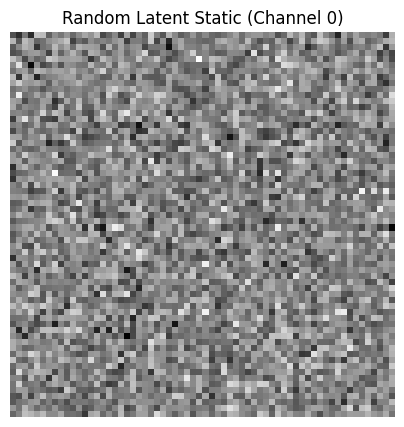

In [24]:
latent_to_plot = random_latents[0, 0].cpu().numpy()

# Plot the array
plt.figure(figsize=(5, 5))
plt.imshow(latent_to_plot, cmap="gray")
plt.title("Random Latent Static (Channel 0)")
plt.axis("off") # Hides the axis numbers
plt.show()

In [25]:
latents = random_latents
# Decode the latents
with torch.no_grad():
    scaling_factor = torch.tensor(vae.config.scaling_factor, device=device, dtype=dtype)
    decoded = vae.decode(latents / scaling_factor).sample

In [26]:
print("Shape:", latents)

Shape: tensor([[[[-1.4365, -2.3574, -0.3735,  ..., -0.3420, -1.9736,  1.1094],
          [ 1.2617, -1.2529,  1.4160,  ...,  0.0710,  1.0342,  1.3213],
          [-1.2080,  0.0563,  1.2002,  ...,  1.5039, -2.1094,  0.5400],
          ...,
          [-1.1865, -0.4844, -0.2460,  ..., -0.1053, -0.1013,  1.3438],
          [ 0.4453, -0.4795,  1.3193,  ..., -0.8213,  0.4526,  0.1301],
          [-0.8442, -0.0327,  1.5430,  ...,  0.1395,  0.9902, -0.4880]],

         [[-1.8535,  0.1289,  0.6328,  ..., -1.0830, -0.7402, -0.7798],
          [ 0.0390,  0.1205,  0.3723,  ..., -0.4832, -0.5835,  0.6982],
          [ 0.5078, -0.6328, -0.0772,  ...,  2.1699, -0.2332, -0.1020],
          ...,
          [ 0.0901,  0.0365, -1.5693,  ..., -0.4714,  0.4373,  0.6152],
          [ 0.3928, -0.8218,  0.3232,  ...,  0.0579, -1.8252, -0.7803],
          [ 0.9575,  1.0156, -0.4536,  ...,  0.9165,  0.6030, -0.3738]],

         [[ 1.3545,  0.1853, -1.1396,  ..., -1.6826, -0.2705, -1.3828],
          [-0.7275,  0.

In [27]:
# Permute the dimensions and convert to NumPy
unscaled = decoded.permute(0, 2, 3, 1).cpu().numpy()
print("Shape:", unscaled.shape)

Shape: (1, 512, 512, 3)


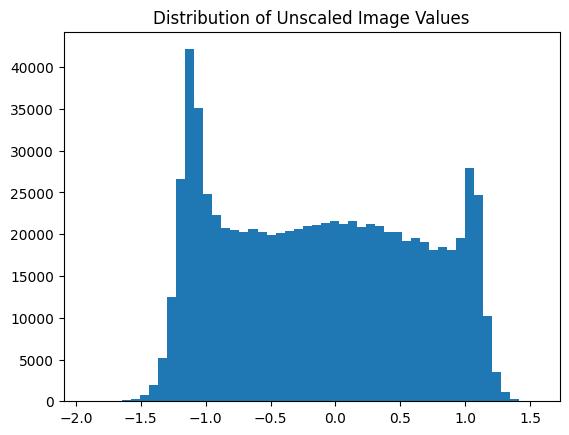

In [28]:
# Plot a histogram of the values in the array
plt.hist(
    unscaled.flatten(),
    bins=50,
);
plt.title("Distribution of Unscaled Image Values")
plt.show()

In [29]:
# Scale the image values to be between 0 and 255
scaled = ((unscaled + 1) * 255 / 2).clip(0, 255).round().astype("uint8")

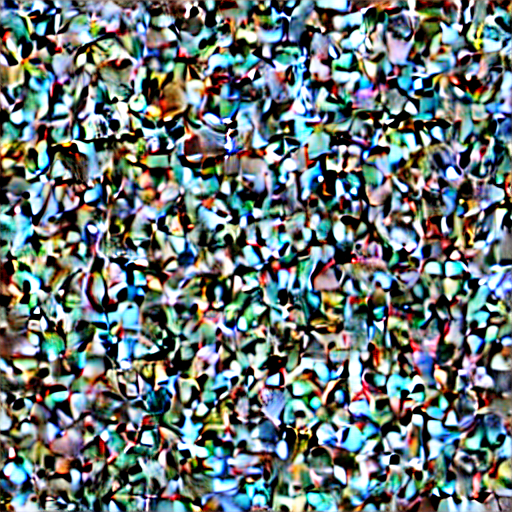

In [30]:
image = Image.fromarray(scaled[0])
image

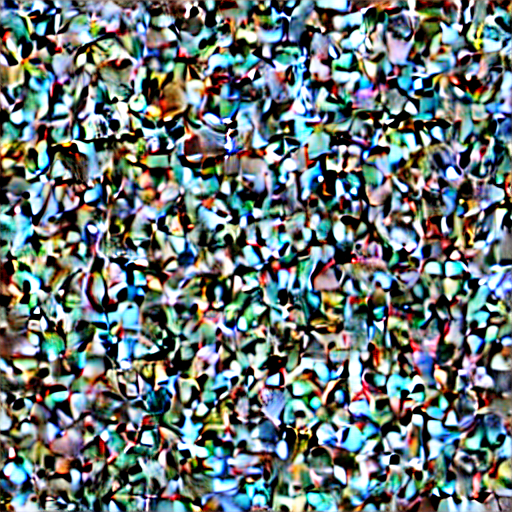

In [31]:
def latents_to_image(latents, vae=vae):
    """Transform the latent vector to a image, using a VAE decoder.

    Inputs:  latents  Latent vector(s) as a 4-D PyTorch tensor.  Only
                      the first element of the batch will be used.
             vae      The VAE used to decode the image from latents.

    Outputs: A PIL image corresponding to the latents.
    """
    # Scaling factor
    scaling_factor = torch.tensor(vae.config.scaling_factor, device=device, dtype=dtype)

    # Decode the latents
    with torch.no_grad():
        decoded = vae.decode(latents / scaling_factor).sample

    # Permute the dimensions and convert to NumPy
    unscaled = decoded.permute(0, 2, 3, 1).cpu().numpy()

    # Scale the image values to be between 0 and 255
    scaled = ((unscaled + 1) * 255 / 2).clip(0, 255).round().astype("uint8")

    # Return a PIL image (grabbing the first one in the batch)
    return Image.fromarray(scaled[0])

# Test the function with your random latents
latents_to_image(random_latents)

# Denoising Diffusion

In [32]:
unet = diffusers.UNet2DConditionModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="unet",
    torch_dtype=torch.float16,

)
unet.to(device)

summary(unet)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

unet/diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

Layer (type:depth-idx)                                            Param #
UNet2DConditionModel                                              --
├─Conv2d: 1-1                                                     11,840
├─Timesteps: 1-2                                                  --
├─TimestepEmbedding: 1-3                                          --
│    └─Linear: 2-1                                                410,880
│    └─SiLU: 2-2                                                  --
│    └─Linear: 2-3                                                1,639,680
├─ModuleList: 1-4                                                 --
│    └─CrossAttnDownBlock2D: 2-4                                  --
│    │    └─ModuleList: 3-1                                       5,092,480
│    │    └─ModuleList: 3-2                                       4,510,080
│    │    └─ModuleList: 3-3                                       921,920
│    └─CrossAttnDownBlock2D: 2-5                               

In [33]:
scheduler = diffusers.UniPCMultistepScheduler.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="scheduler",

)


scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

In [34]:
latents = random_latents * scheduler.init_noise_sigma

latents.shape

torch.Size([1, 4, 64, 64])

In [35]:
scheduler.set_timesteps(1)
print("Steps:", scheduler.timesteps)

Steps: tensor([999])


In [36]:
t = scheduler.timesteps[0]

print(t)

tensor(999)


In [37]:
latent_inputs = torch.cat([latents, latents], dim=0)

print(latent_inputs.shape)

torch.Size([2, 4, 64, 64])


In [38]:
# Predict the noise
scaled_inputs = scheduler.scale_model_input(latent_inputs, timestep=t)
with torch.no_grad():
    noise = unet(scaled_inputs, t, encoder_hidden_states=all_embeddings)

# Split the unconditioned and conditioned predictions
noise_uncond, noise_cond = noise.sample.chunk(2)

In [39]:
guidance_scale = 7.5  # A pretty middle-of-the-road value
noise_pred = noise_uncond + guidance_scale * (noise_cond - noise_uncond)

print(noise_pred.shape)

torch.Size([1, 4, 64, 64])


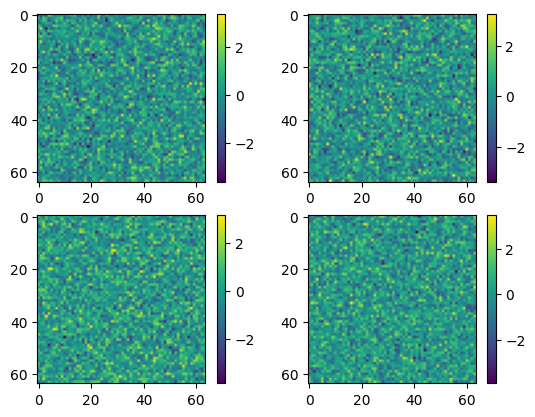

In [40]:
plot_latents(noise_pred)

In [41]:
# Update the variable `latents` based on the predicted noise
latents = scheduler.step(noise_pred, t, latents).prev_sample

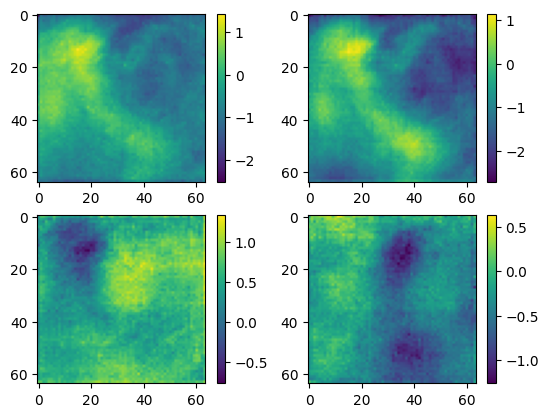

In [42]:
plot_latents(latents)

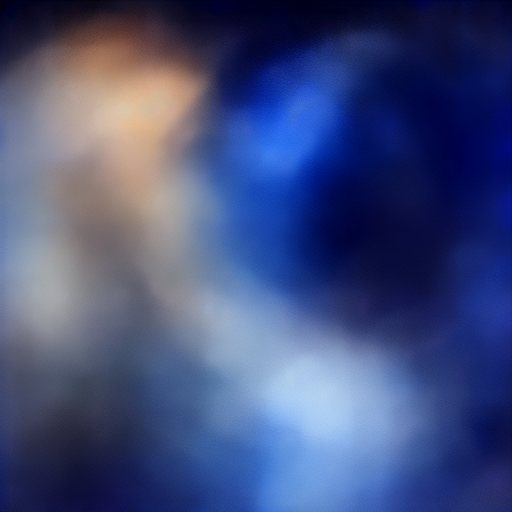

In [43]:
# Decode the latent vector to an image
latents_to_image(latents)

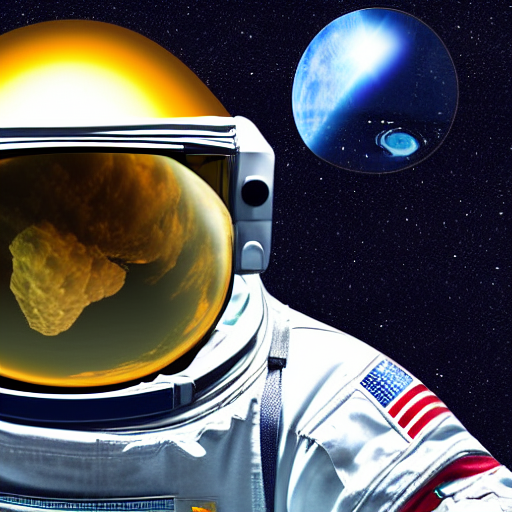

  0%|          | 0/50 [00:00<?, ?it/s]

In [44]:
num_steps = 50
scheduler.set_timesteps(num_steps)


latents = random_latents * scheduler.init_noise_sigma


display_handle = display(latents_to_image(latents, vae), display_id="latent_display")

# The standard guidance scale for Classifier-Free Guidance (CFG)
guidance_scale = 7.5

with torch.no_grad():
    for t in tqdm(scheduler.timesteps):
        # Assemble the latent inputs (Duplicate for CFG)
        latent_inputs = torch.cat([latents, latents], dim=0)
        # Schedulers often need to scale the latents based on the current timestep
        latent_inputs = scheduler.scale_model_input(latent_inputs, t)

        # Predict the noise using the UNet
        noise_pred = unet(latent_inputs, t, encoder_hidden_states=all_embeddings).sample

        # Split the unconditioned and conditioned predictions
        # .chunk(2) splits the batch of 2 back into two separate tensors
        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)

        # Combine the predictions according to the guidance scale (CFG Formula)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        # Update the variable `latents` based on the predicted noise
        # The scheduler handles the complex math of subtracting the noise prediction
        latents = scheduler.step(noise_pred, t, latents).prev_sample

        # This will update the image based on the current latent vector.
        display_handle.update(latents_to_image(latents, vae))